In [8]:
import pandas as pd
import numpy as np
from pathlib import Path
import sys

BASE_DIR = Path().resolve().parent
sys.path.append(str(BASE_DIR / 'scripts'))

In [9]:
df = pd.read_csv(BASE_DIR / 'data' / 'datos_prueba.csv')

In [10]:
from tools import preprocesar
df = preprocesar(df)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   conteo_retrasos            9000 non-null   int64  
 1   comportamiento_septiembre  9000 non-null   int64  
 2   conteo_meses_inactivos     9000 non-null   int64  
 3   conteo_impagos             9000 non-null   int64  
 4   abono_promedio             9000 non-null   float64
 5   utilizacion_septiembre     9000 non-null   float64
 6   estado_cuenta_septiembre   9000 non-null   int64  
 7   DEFAULT                    9000 non-null   int64  
dtypes: float64(2), int64(6)
memory usage: 562.6 KB


In [11]:
X = df.drop(columns=['DEFAULT'])
y = df['DEFAULT']

AUC-ROC : 0.7435
Gini    : 0.4869
KS      : 0.3953

Threshold : 0.75
TP        : 631
FP        : 365
TN        : 6644
FN        : 1360
Precision : 0.6335
Recall    : 0.3169
F1        : 0.4225


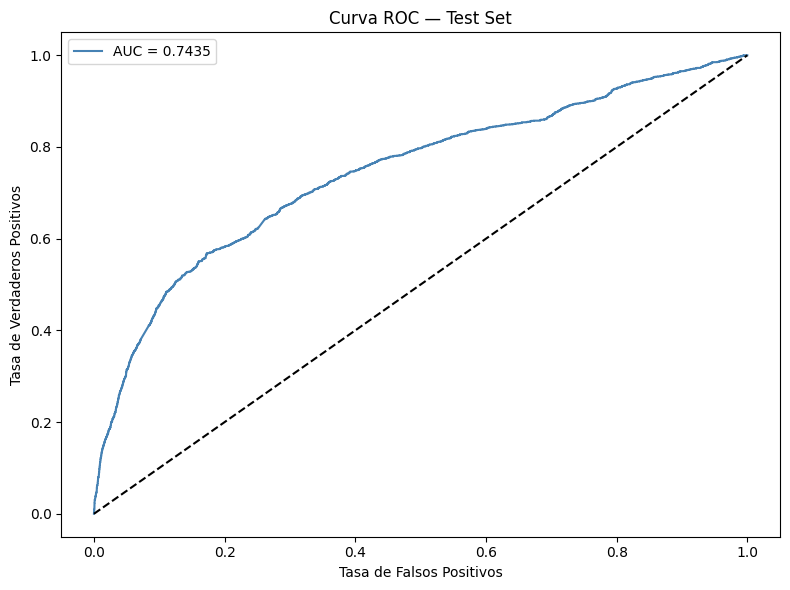

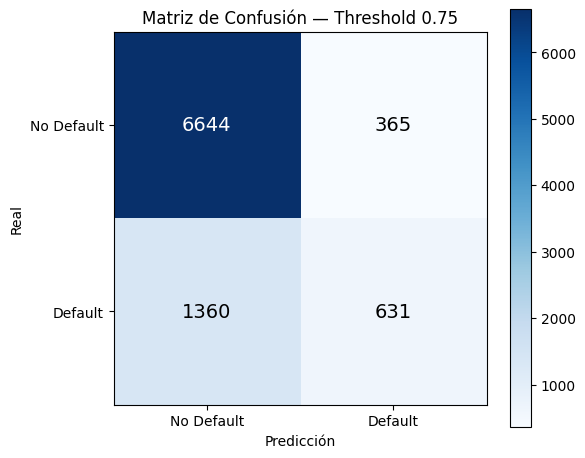

In [13]:
from pathlib import Path
import joblib
from modelos import evaluar_test

MODELS_DIR = Path().resolve()

logistica = joblib.load(MODELS_DIR / 'logistica.pkl')
evaluar_test(X, y, logistica, threshold=0.75);

AUC-ROC : 0.7788
Gini    : 0.5576
KS      : 0.4212

Threshold : 0.7
TP        : 833
FP        : 510
TN        : 6499
FN        : 1158
Precision : 0.6203
Recall    : 0.4184
F1        : 0.4997


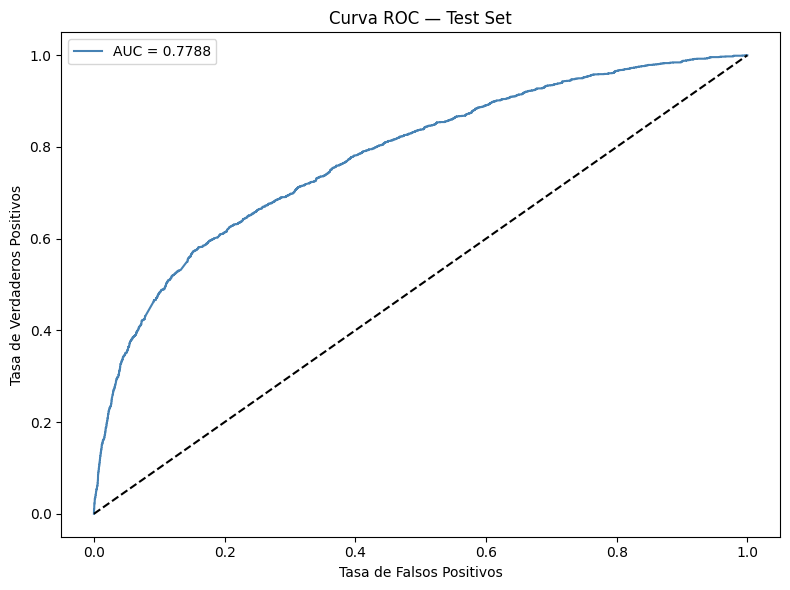

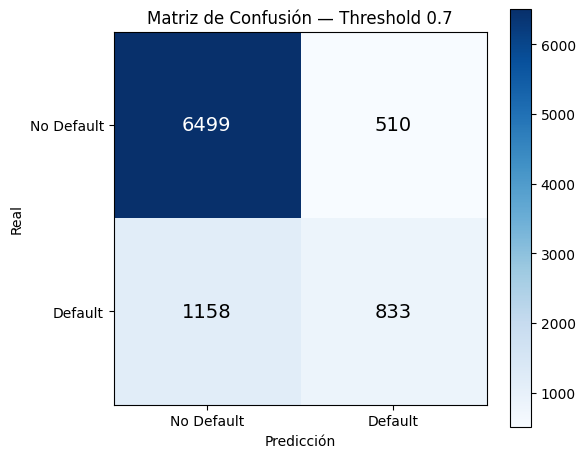

In [15]:
xgboost = joblib.load(MODELS_DIR / 'xgboost.pkl')
evaluar_test(X, y, xgboost, threshold=0.70);